In [1]:
import pandas as pd

data = pd.read_csv("D:\Real-Time-Fraud-Detection\dataset\creditcard.csv")

data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [3]:
data['Class'].value_counts()

0    284315
1       492
Name: Class, dtype: int64

In [4]:
# ── Data Handling ──────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── ML: Preprocessing ──────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── ML: Model ──────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

# ── ML: Evaluation ─────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# ── Imbalanced Data Handling ────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Utilities ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Notebook display settings
pd.set_option('display.max_columns', 35)
pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline
sns.set_style('whitegrid')
sns.set_palette('Set2')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [5]:
# Load the dataset
df = pd.read_csv("D:\Real-Time-Fraud-Detection\dataset\creditcard.csv")

print(f"📊 Dataset Shape: {df.shape}")
print(f"📋 Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print("\n🔍 First 5 rows:")
df.head()

📊 Dataset Shape: (284807, 31)
📋 Rows: 284,807  |  Columns: 31

🔍 First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [6]:
# ── Basic Info ─────────────────────────────────────────────────
print("=" * 60)
print("📋 DATASET INFORMATION")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("❓ MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found!")

print("\n" + "=" * 60)
print("🔢 DUPLICATE ROWS")
print("=" * 60)
print(f"Duplicates: {df.duplicated().sum()}")

📋 DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  f

In [7]:
# ── Class Distribution ─────────────────────────────────────────
print("=" * 60)
print("⚖️  CLASS DISTRIBUTION (Fraud vs Normal)")
print("=" * 60)

class_counts = df['Class'].value_counts()
class_percent = df['Class'].value_counts(normalize=True) * 100

class_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percent.round(4)
})
class_df.index = ['Normal (0)', 'Fraud (1)']
print(class_df)

print(f"""
💡 KEY INSIGHT:
   Normal transactions : {class_counts[0]:,}
   Fraudulent transactions : {class_counts[1]:,}
   Fraud % : {class_percent[1]:.4f}%

⚠️  This is a HIGHLY IMBALANCED dataset.
   We must handle this to avoid a biased model!
""")

⚖️  CLASS DISTRIBUTION (Fraud vs Normal)
             Count  Percentage
Normal (0)  284315     99.8273
Fraud (1)      492      0.1727

💡 KEY INSIGHT:
   Normal transactions : 284,315
   Fraudulent transactions : 492
   Fraud % : 0.1727%

⚠️  This is a HIGHLY IMBALANCED dataset.
   We must handle this to avoid a biased model!



In [8]:
# ── Statistical Summary ────────────────────────────────────────
print("📊 Statistical Summary (Amount & Time):")
df[['Time', 'Amount']].describe().round(2)

📊 Statistical Summary (Amount & Time):


,Time,Amount
count,284807.0000,284807.0000
mean,94813.8600,88.3500
std,47488.1500,250.1200
min,0.0000,0.0000
25%,54201.5000,5.6000
50%,84692.0000,22.0000
75%,139320.5000,77.1600
max,172792.0000,25691.1600


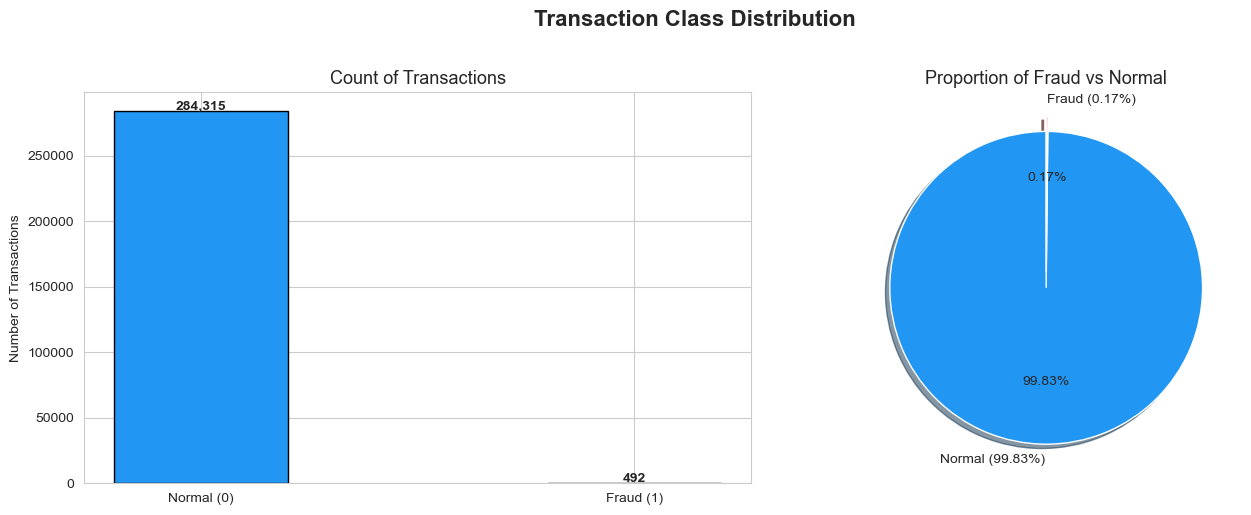

💾 Plot saved to outputs


In [9]:
# ── Plot 1: Class Distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transaction Class Distribution', fontsize=16, fontweight='bold', y=1.02)

# Bar Chart
colors = ['#2196F3', '#F44336']
axes[0].bar(['Normal (0)', 'Fraud (1)'], class_counts.values, color=colors, edgecolor='black', width=0.4)
axes[0].set_title('Count of Transactions', fontsize=13)
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie Chart
axes[1].pie(
    class_counts.values,
    labels=['Normal (99.83%)', 'Fraud (0.17%)'],
    colors=colors,
    autopct='%1.2f%%',
    startangle=90,
    explode=(0, 0.1),
    shadow=True
)
axes[1].set_title('Proportion of Fraud vs Normal', fontsize=13)

plt.tight_layout()
plt.savefig("D:/Real-Time-Fraud-Detection/outputs", dpi=150, bbox_inches='tight')
plt.show()
print("💾 Plot saved to outputs")

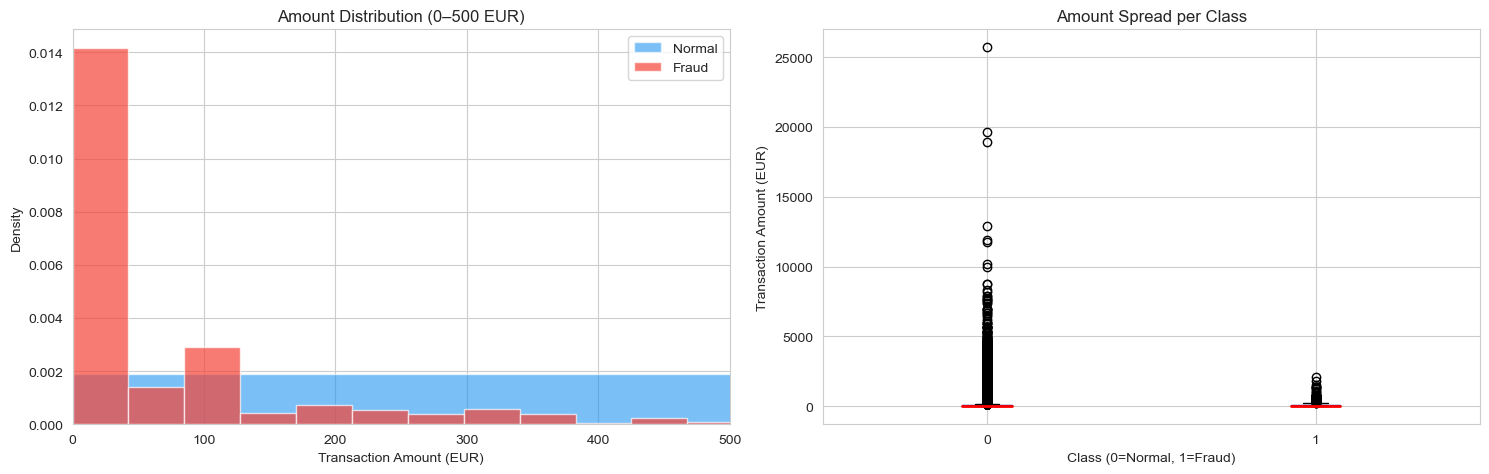

In [10]:
# ── Plot 2: Transaction Amount — Fraud vs Normal ───────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Transaction Amount: Fraud vs Normal', fontsize=16, fontweight='bold')

fraud    = df[df['Class'] == 1]['Amount']
normal   = df[df['Class'] == 0]['Amount']

# Distribution
axes[0].hist(normal, bins=50, alpha=0.6, color='#2196F3', label='Normal', density=True)
axes[0].hist(fraud,  bins=50, alpha=0.7, color='#F44336', label='Fraud',  density=True)
axes[0].set_xlim([0, 500])
axes[0].set_title('Amount Distribution (0–500 EUR)', fontsize=12)
axes[0].set_xlabel('Transaction Amount (EUR)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Box Plot
df.boxplot(column='Amount', by='Class', ax=axes[1],
           boxprops=dict(color='navy'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Amount Spread per Class', fontsize=12)
axes[1].set_xlabel('Class (0=Normal, 1=Fraud)')
axes[1].set_ylabel('Transaction Amount (EUR)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('D:/Real-Time-Fraud-Detection/outputs/02_amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

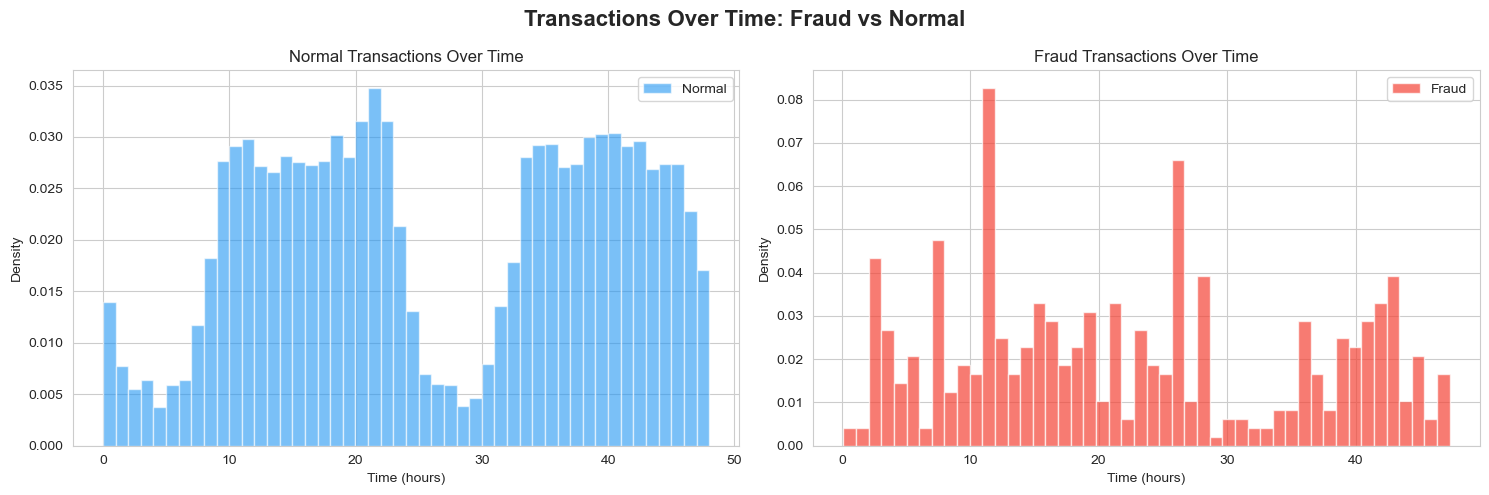

💡 Insight: Fraud transactions are more uniformly spread across time.
   Normal transactions show a daily pattern (peak during business hours).


In [11]:
# ── Plot 3: Transaction Time Analysis ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Transactions Over Time: Fraud vs Normal', fontsize=16, fontweight='bold')

fraud_time  = df[df['Class'] == 1]['Time'] / 3600   # Convert to hours
normal_time = df[df['Class'] == 0]['Time'] / 3600

axes[0].hist(normal_time, bins=48, alpha=0.6, color='#2196F3', label='Normal', density=True)
axes[0].set_title('Normal Transactions Over Time', fontsize=12)
axes[0].set_xlabel('Time (hours)')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].hist(fraud_time, bins=48, alpha=0.7, color='#F44336', label='Fraud', density=True)
axes[1].set_title('Fraud Transactions Over Time', fontsize=12)
axes[1].set_xlabel('Time (hours)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('D:/Real-Time-Fraud-Detection/outputs/03_time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Insight: Fraud transactions are more uniformly spread across time.")
print("   Normal transactions show a daily pattern (peak during business hours).")

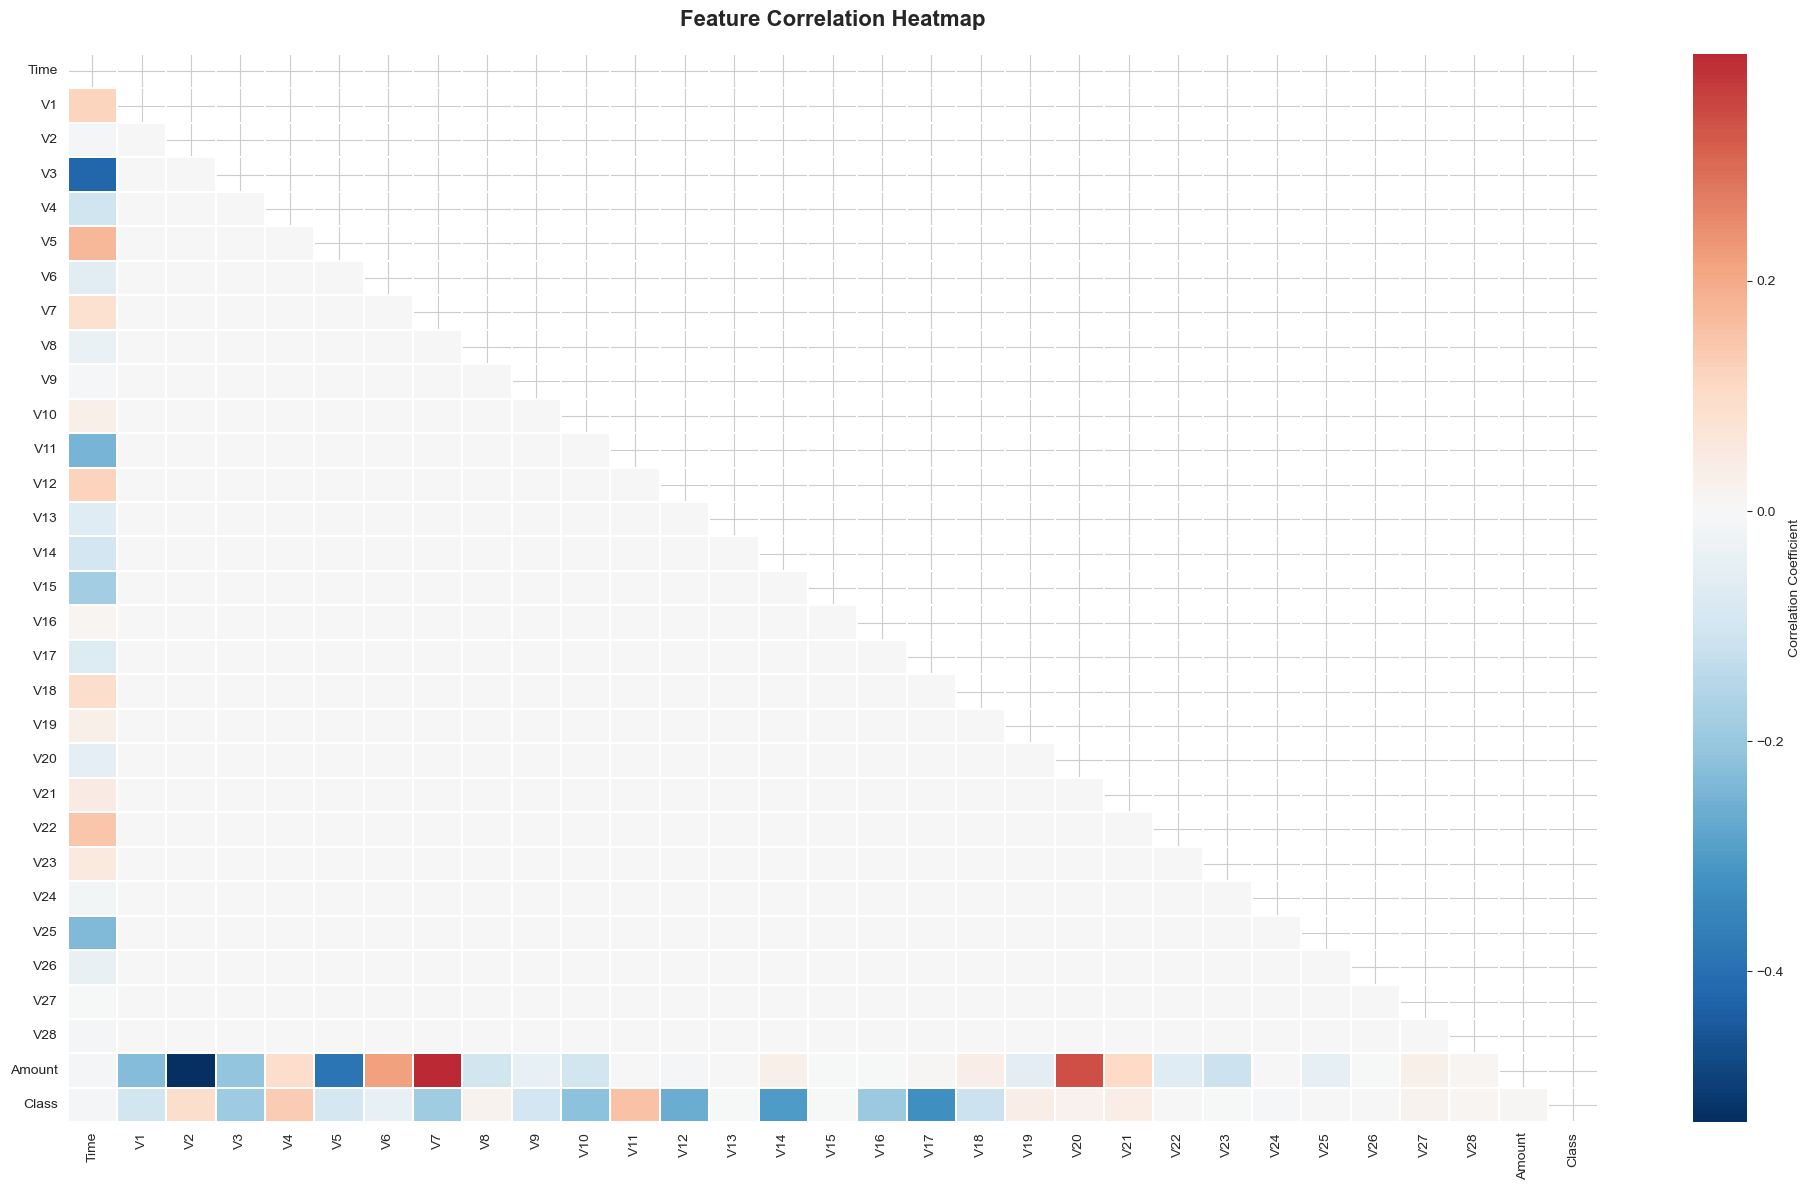

💡 The V-features are mostly uncorrelated (they're PCA components).


In [12]:
# ── Plot 4: Correlation Heatmap ────────────────────────────────
plt.figure(figsize=(20, 12))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='RdBu_r',
    center=0,
    linewidths=0.3,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('D:/Real-Time-Fraud-Detection/outputs/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 The V-features are mostly uncorrelated (they're PCA components).")

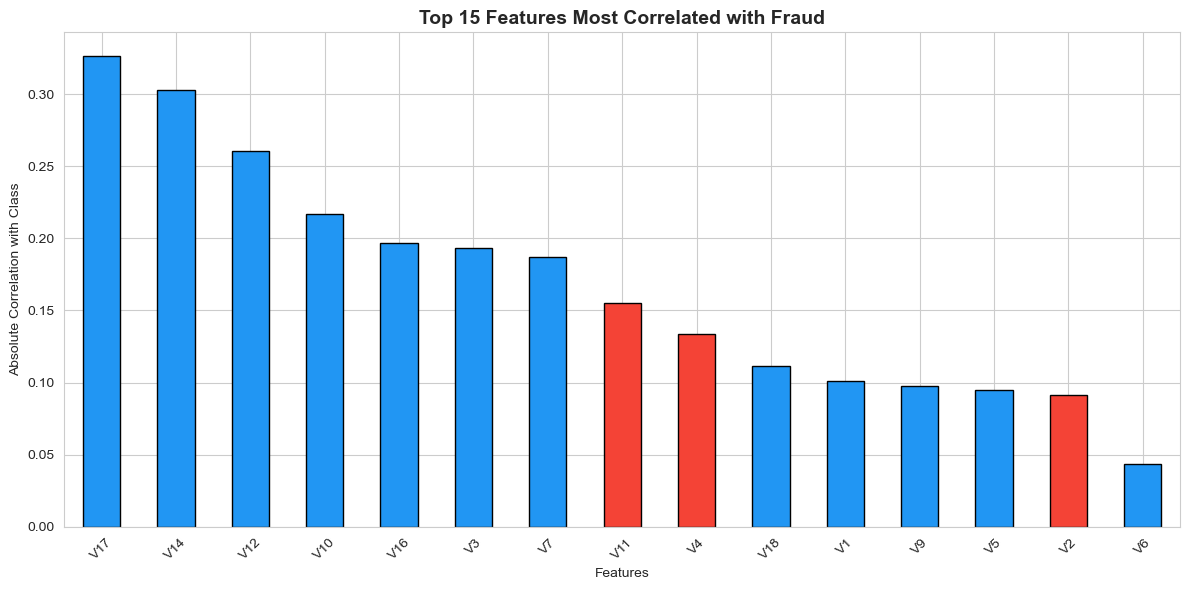

🏆 Top feature correlated with fraud: V17 (0.3265)


In [13]:
# ── Plot 5: Top Features Correlated with Fraud ─────────────────
fraud_corr = corr_matrix['Class'].drop('Class').abs().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors_bar = ['#F44336' if v > 0 else '#2196F3'
              for v in corr_matrix['Class'].drop('Class').loc[fraud_corr.index]]
fraud_corr.head(15).plot(kind='bar', color=colors_bar[:15], edgecolor='black')
plt.title('Top 15 Features Most Correlated with Fraud', fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Absolute Correlation with Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('D:/Real-Time-Fraud-Detection/outputs/05_feature_importance_corr.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"🏆 Top feature correlated with fraud: {fraud_corr.index[0]} ({fraud_corr.iloc[0]:.4f})")

In [14]:
# ── 5.1 Remove Duplicates ──────────────────────────────────────
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"   Removed {before - after} duplicate rows")
print(f"   Dataset size: {before:,} → {after:,}")

   Removed 1081 duplicate rows
   Dataset size: 284,807 → 283,726


In [15]:
# ── 5.2 Feature Scaling ────────────────────────────────────────
# We scale 'Time' and 'Amount' to bring them to the same range as V1-V28

scaler = StandardScaler()

df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_Scaled']   = scaler.fit_transform(df[['Time']])

# Drop original unscaled columns
df.drop(columns=['Amount', 'Time'], inplace=True)

print("✅ Feature scaling applied to 'Amount' and 'Time'")
print(f"   Amount_Scaled — mean: {df['Amount_Scaled'].mean():.4f}, std: {df['Amount_Scaled'].std():.4f}")
print(f"   Time_Scaled   — mean: {df['Time_Scaled'].mean():.4f}, std: {df['Time_Scaled'].std():.4f}")
df.head(3)

✅ Feature scaling applied to 'Amount' and 'Time'
   Amount_Scaled — mean: -0.0000, std: 1.0000
   Time_Scaled   — mean: 0.0000, std: 1.0000


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class,Amount_Scaled,Time_Scaled
0,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,0,0.2442,-1.9968
1,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,0,-0.3426,-1.9968
2,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,0,1.1589,-1.9968


In [16]:
# ── 5.3 Define Features (X) and Target (y) ────────────────────
X = df.drop(columns=['Class'])   # All columns except the label
y = df['Class']                   # Target: 0=Normal, 1=Fraud

print(f"📐 Feature matrix X shape : {X.shape}")
print(f"🎯 Target vector y shape  : {y.shape}")
print(f"\n   Features used ({X.shape[1]}): {list(X.columns)}")

📐 Feature matrix X shape : (283726, 30)
🎯 Target vector y shape  : (283726,)

   Features used (30): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_Scaled', 'Time_Scaled']


In [17]:
# ── 5.4 Train-Test Split ───────────────────────────────────────
# 80% for training, 20% for testing
# stratify=y ensures both splits have the same fraud/normal ratio

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y         # ← Very important for imbalanced datasets!
)

print("✅ Train-Test Split Complete")
print(f"   Training set   : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Testing set    : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\n   Fraud in train : {y_train.sum():,} ({y_train.mean()*100:.3f}%)")
print(f"   Fraud in test  : {y_test.sum():,}  ({y_test.mean()*100:.3f}%)")

✅ Train-Test Split Complete
   Training set   : 226,980 rows (80.0%)
   Testing set    : 56,746 rows (20.0%)

   Fraud in train : 378 (0.167%)
   Fraud in test  : 95  (0.167%)


In [19]:
# ── 5.5 Handle Class Imbalance with SMOTE ─────────────────────
# SMOTE = Synthetic Minority Over-sampling Technique
# It creates synthetic fraud examples so the model learns fraud patterns better
# IMPORTANT: SMOTE is applied ONLY on training data, NEVER on test data!

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

print("Before SMOTE:")
print(f"   Normal : {(y_train == 0).sum():,}")
print(f"   Fraud  : {(y_train == 1).sum():,}")

smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE (training set only):")
print(f"   Normal : {(y_train_sm == 0).sum():,}")
print(f"   Fraud  : {(y_train_sm == 1).sum():,}")
print(f"\n✅ SMOTE applied. Training set now more balanced.")
print("   (Test set remains untouched tp preserve real-world distribution)")

Before SMOTE:
   Normal : 226,602
   Fraud  : 378

After SMOTE (training set only):
   Normal : 226,602
   Fraud  : 113,301

✅ SMOTE applied. Training set now more balanced.
   (Test set remains untouched tp preserve real-world distribution)


In [20]:
import time

# ── Build and Train the Model ──────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1             # Use all CPU cores for faster training
)

print("🌲 Training Random Forest...")
start = time.time()
rf_model.fit(X_train_sm, y_train_sm)
end   = time.time()

print(f"✅ Model trained in {end - start:.2f} seconds")
print(f"   Trees in forest : {rf_model.n_estimators}")
print(f"   Features used   : {rf_model.n_features_in_}")

🌲 Training Random Forest...
✅ Model trained in 159.78 seconds
   Trees in forest : 100
   Features used   : 30


In [21]:
# ── 7.1 Generate Predictions ──────────────────────────────────
y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]  # Probability of being fraud

# ── 7.2 Calculate All Metrics ─────────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_pred_proba)

print("=" * 55)
print("          📊 MODEL PERFORMANCE REPORT")
print("=" * 55)
print(f"  {'Metric':<25} {'Score':>10}")
print("-" * 55)
print(f"  {'Accuracy':<25} {acc:>10.4f}")
print(f"  {'Precision':<25} {prec:>10.4f}")
print(f"  {'Recall (Fraud Catch Rate)':<25} {rec:>10.4f}")
print(f"  {'F1-Score':<25} {f1:>10.4f}")
print(f"  {'ROC-AUC':<25} {auc:>10.4f}")
print("=" * 55)

print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

          📊 MODEL PERFORMANCE REPORT
  Metric                         Score
-------------------------------------------------------
  Accuracy                      0.9987
  Precision                     0.5878
  Recall (Fraud Catch Rate)     0.8105
  F1-Score                      0.6814
  ROC-AUC                       0.9752

📋 Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.59      0.81      0.68        95

    accuracy                           1.00     56746
   macro avg       0.79      0.90      0.84     56746
weighted avg       1.00      1.00      1.00     56746



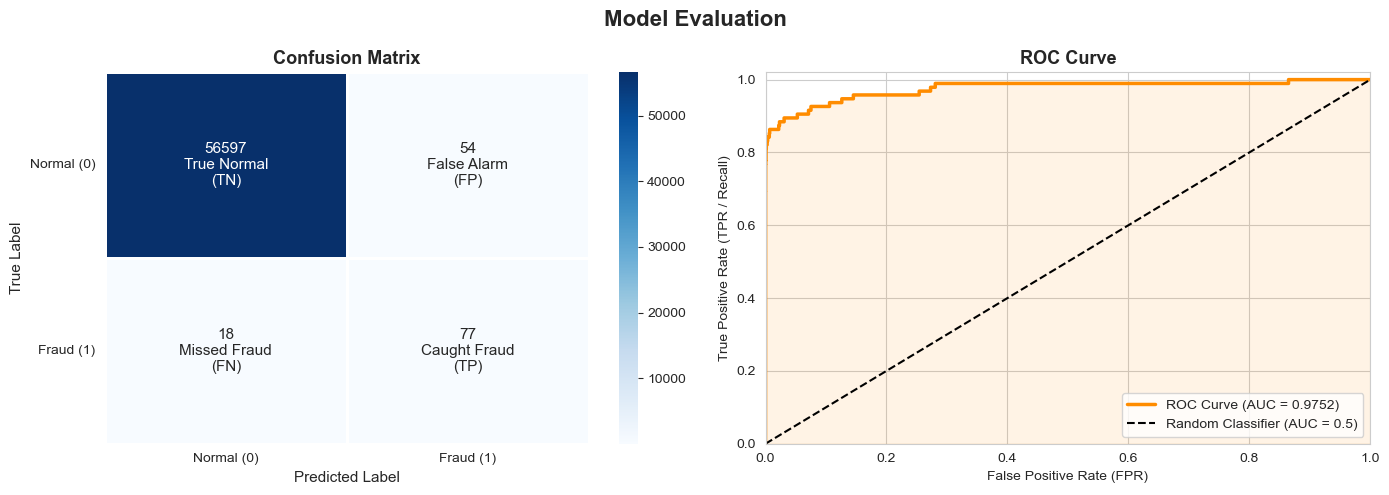


🔍 Confusion Matrix Breakdown:
   ✅ True Negatives  (correctly said Normal) : 56,597
   ⚠️  False Positives (Normal → predicted Fraud): 54
   ❌ False Negatives (Fraud → missed!)       : 18
   🎯 True Positives  (correctly caught Fraud) : 77


In [23]:
# ── 7.3 Confusion Matrix ───────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation', fontsize=16, fontweight='bold')

# Confusion Matrix Heatmap
cm_labels = [['True Normal\n(TN)', 'False Alarm\n(FP)'],
             ['Missed Fraud\n(FN)', 'Caught Fraud\n(TP)']]

sns.heatmap(
    cm, annot=np.array([[f"{cm[i][j]}\n{cm_labels[i][j]}" for j in range(2)] for i in range(2)]),
    fmt='', cmap='Blues', ax=axes[0],
    linewidths=2, linecolor='white',
    annot_kws={'size': 11}
)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xticklabels(['Normal (0)', 'Fraud (1)'], fontsize=10)
axes[0].set_yticklabels(['Normal (0)', 'Fraud (1)'], fontsize=10, rotation=0)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR / Recall)')
axes[1].legend(loc='lower right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('D:/Real-Time-Fraud-Detection/outputs/06_confusion_matrix_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🔍 Confusion Matrix Breakdown:")
print(f"   ✅ True Negatives  (correctly said Normal) : {cm[0][0]:,}")
print(f"   ⚠️  False Positives (Normal → predicted Fraud): {cm[0][1]:,}")
print(f"   ❌ False Negatives (Fraud → missed!)       : {cm[1][0]:,}")
print(f"   🎯 True Positives  (correctly caught Fraud) : {cm[1][1]:,}")

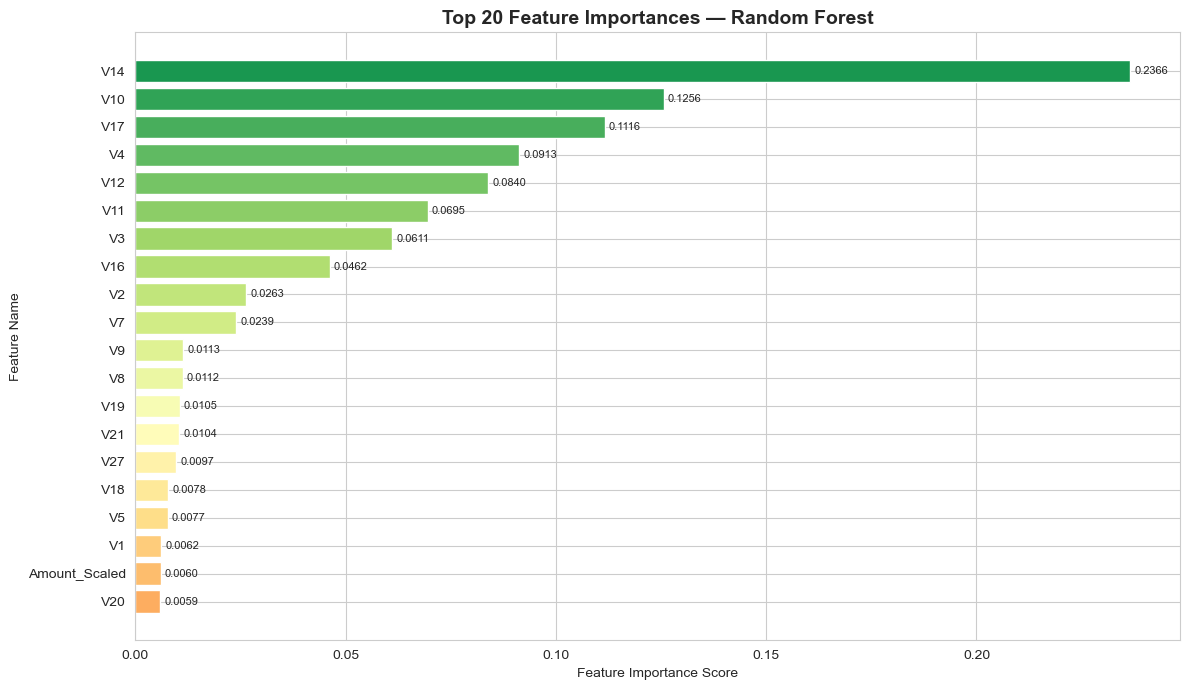

🏆 Most important feature: V14
   Importance score: 0.2366


In [25]:
# ── 7.4 Feature Importance ────────────────────────────────────
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 7))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 20))
bars = plt.barh(
    feature_importance['Feature'].head(20)[::-1],
    feature_importance['Importance'].head(20)[::-1],
    color=colors
)
plt.title('Top 20 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name')

for bar, val in zip(bars, feature_importance['Importance'].head(20)[::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('D:/Real-Time-Fraud-Detection/outputs/07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"🏆 Most important feature: {feature_importance.iloc[0]['Feature']}")
print(f"   Importance score: {feature_importance.iloc[0]['Importance']:.4f}")

In [26]:
def predict_fraud(transaction_data, model=rf_model, feature_names=X.columns, scaler_ref=scaler):
    """
    Real-Time Fraud Detection Function
    
    Parameters:
    -----------
    transaction_data : dict
        Dictionary with transaction features (V1-V28, Amount, Time)
    
    Returns:
    --------
    dict: Prediction result with verdict, confidence, and risk level
    """
    # Convert input to DataFrame
    input_df = pd.DataFrame([transaction_data])
    
    # Scale Amount and Time if provided in original form
    if 'Amount' in input_df.columns:
        input_df['Amount_Scaled'] = scaler_ref.transform(input_df[['Amount']])
        input_df.drop(columns=['Amount'], inplace=True)
    if 'Time' in input_df.columns:
        input_df['Time_Scaled'] = scaler_ref.transform(input_df[['Time']])
        input_df.drop(columns=['Time'], inplace=True)
    
    # Ensure column order matches training
    input_df = input_df.reindex(columns=feature_names, fill_value=0)
    
    # Get prediction and probability
    prediction   = model.predict(input_df)[0]
    fraud_prob   = model.predict_proba(input_df)[0][1]
    normal_prob  = model.predict_proba(input_df)[0][0]
    
    # Risk level
    if fraud_prob >= 0.80:
        risk = '🔴 HIGH RISK'
    elif fraud_prob >= 0.50:
        risk = '🟠 MEDIUM RISK'
    elif fraud_prob >= 0.20:
        risk = '🟡 LOW RISK'
    else:
        risk = '🟢 VERY LOW RISK'
    
    result = {
        'verdict'         : '🚨 FRAUD DETECTED' if prediction == 1 else '✅ NORMAL TRANSACTION',
        'prediction'      : int(prediction),
        'fraud_probability': round(fraud_prob * 100, 2),
        'normal_probability': round(normal_prob * 100, 2),
        'risk_level'      : risk
    }
    return result


def display_prediction(result):
    """Pretty-print the fraud prediction result."""
    print("\n" + "=" * 55)
    print("       🔍 FRAUD DETECTION SYSTEM — RESULT")
    print("=" * 55)
    print(f"  VERDICT          : {result['verdict']}")
    print(f"  RISK LEVEL       : {result['risk_level']}")
    print("-" * 55)
    print(f"  Fraud Probability  : {result['fraud_probability']:.2f}%")
    print(f"  Normal Probability : {result['normal_probability']:.2f}%")
    print("=" * 55 + "\n")


print("✅ Fraud Prediction System ready!")

✅ Fraud Prediction System ready!


In [38]:
# ── Test 1: Known Fraud Transaction (from test set) ────────────
print("🧪 TEST 1: Known FRAUD transaction from dataset")
fraud_samples = X_test[y_test == 1]
fraud_tx = fraud_samples.iloc[5].to_dict()

result1 = predict_fraud(fraud_tx)
display_prediction(result1)

🧪 TEST 1: Known FRAUD transaction from dataset

       🔍 FRAUD DETECTION SYSTEM — RESULT
  VERDICT          : 🚨 FRAUD DETECTED
  RISK LEVEL       : 🔴 HIGH RISK
-------------------------------------------------------
  Fraud Probability  : 96.58%
  Normal Probability : 3.42%



In [39]:
# ── Test 2: Known Normal Transaction ──────────────────────────
print("🧪 TEST 2: Known NORMAL transaction from dataset")
normal_samples = X_test[y_test == 0]
normal_tx = normal_samples.iloc[0].to_dict()

result2 = predict_fraud(normal_tx)
display_prediction(result2)

🧪 TEST 2: Known NORMAL transaction from dataset

       🔍 FRAUD DETECTION SYSTEM — RESULT
  VERDICT          : ✅ NORMAL TRANSACTION
  RISK LEVEL       : 🟢 VERY LOW RISK
-------------------------------------------------------
  Fraud Probability  : 0.83%
  Normal Probability : 99.17%



In [40]:
# ── Test 3: Custom Simulated Transaction ──────────────────────
print("🧪 TEST 3: Custom simulated transaction")

# This simulates a transaction using average values from dataset
custom_transaction = {col: float(X[col].mean()) for col in X.columns}
# Modify a few features to simulate suspicious behavior
custom_transaction['V14'] = -8.0    # V14 is highly correlated with fraud
custom_transaction['V4']  = 4.5
custom_transaction['V11'] = -5.0

result3 = predict_fraud(custom_transaction)
display_prediction(result3)

🧪 TEST 3: Custom simulated transaction

       🔍 FRAUD DETECTION SYSTEM — RESULT
  VERDICT          : ✅ NORMAL TRANSACTION
  RISK LEVEL       : 🟡 LOW RISK
-------------------------------------------------------
  Fraud Probability  : 22.34%
  Normal Probability : 77.66%



In [76]:
print("BATCH PREDICTION: First 10 Test Transactions")
print("=" * 90)

sample_10 = X_test.head(10)
actual_10 = y_test.head(10).values

# Header
print(f"{'Transaction':<12} {'Actual':<10} {'Predicted':<12} {'Fraud %':<10} {'Risk Level':<22} {'Match'}")
print("-" * 90)

# Loop through transactions
for i, (idx, row) in enumerate(sample_10.iterrows()):

    # Predict
    r = predict_fraud(row.to_dict())

    # Actual label
    actual_label = 'FRAUD' if actual_10[i] == 1 else 'NORMAL'

    # Predicted label
    predicted_label = 'FRAUD' if r['prediction'] == 1 else 'NORMAL'

    # Match symbol
    match = '✔' if actual_10[i] == r['prediction'] else '✘'

    # Print aligned row
    print(f"{f'#{i+1}':<12} "
          f"{actual_label:<10} "
          f"{predicted_label:<12} "
          f"{str(round(r['fraud_probability'],2)) + '%':<10} "
          f"{r['risk_level']:<22} "
          f"{match}")

BATCH PREDICTION: First 10 Test Transactions
Transaction  Actual     Predicted    Fraud %    Risk Level             Match
------------------------------------------------------------------------------------------
#1           NORMAL     NORMAL       0.83%      🟢 VERY LOW RISK        ✔
#2           NORMAL     NORMAL       1.08%      🟢 VERY LOW RISK        ✔
#3           NORMAL     NORMAL       13.22%     🟢 VERY LOW RISK        ✔
#4           NORMAL     NORMAL       1.32%      🟢 VERY LOW RISK        ✔
#5           NORMAL     NORMAL       15.04%     🟢 VERY LOW RISK        ✔
#6           NORMAL     NORMAL       1.03%      🟢 VERY LOW RISK        ✔
#7           NORMAL     NORMAL       1.59%      🟢 VERY LOW RISK        ✔
#8           NORMAL     NORMAL       0.99%      🟢 VERY LOW RISK        ✔
#9           NORMAL     NORMAL       10.65%     🟢 VERY LOW RISK        ✔
#10          NORMAL     NORMAL       0.92%      🟢 VERY LOW RISK        ✔


In [75]:
print("BATCH PREDICTION: Transactions 100–109")
print("=" * 90)

sample_10 = X_test.iloc[100:110]
actual_10 = y_test.iloc[100:110].values

# Header
print(f"{'Transaction':<12} {'Actual':<10} {'Predicted':<12} {'Fraud %':<10} {'Risk Level':<22} {'Match'}")
print("-" * 90)

# Loop through transactions
for i, (idx, row) in enumerate(sample_10.iterrows()):

    # Predict
    r = predict_fraud(row.to_dict())

    # Actual label
    actual_label = 'FRAUD' if actual_10[i] == 1 else 'NORMAL'

    # Predicted label
    predicted_label = 'FRAUD' if r['prediction'] == 1 else 'NORMAL'

    # Match
    match = '✔' if actual_10[i] == r['prediction'] else '✘'

    # Print aligned row
    print(f"{f'#{i+1}':<12} "
          f"{actual_label:<10} "
          f"{predicted_label:<12} "
          f"{str(round(r['fraud_probability'],2)) + '%':<10} "
          f"{r['risk_level']:<22} "
          f"{match}")

BATCH PREDICTION: Transactions 100–109
Transaction  Actual     Predicted    Fraud %    Risk Level             Match
------------------------------------------------------------------------------------------
#1           NORMAL     NORMAL       3.74%      🟢 VERY LOW RISK        ✔
#2           NORMAL     NORMAL       3.17%      🟢 VERY LOW RISK        ✔
#3           NORMAL     NORMAL       2.49%      🟢 VERY LOW RISK        ✔
#4           NORMAL     NORMAL       2.94%      🟢 VERY LOW RISK        ✔
#5           NORMAL     NORMAL       6.39%      🟢 VERY LOW RISK        ✔
#6           NORMAL     NORMAL       1.24%      🟢 VERY LOW RISK        ✔
#7           NORMAL     NORMAL       2.85%      🟢 VERY LOW RISK        ✔
#8           NORMAL     NORMAL       3.81%      🟢 VERY LOW RISK        ✔
#9           NORMAL     NORMAL       0.82%      🟢 VERY LOW RISK        ✔
#10          NORMAL     NORMAL       1.17%      🟢 VERY LOW RISK        ✔


In [74]:
print("BATCH FRAUD TEST")
print("=" * 85)

# Select first 10 fraud transactions
fraud_sample = X_test[y_test == 1].head(10)
fraud_actual = y_test[y_test == 1].head(10).values

# Header
print(f"{'Transaction':<12} {'Actual':<10} {'Predicted':<12} {'Fraud %':<10} {'Risk Level':<22} {'Match'}")
print("-" * 85)

# Loop through fraud transactions
for i, (idx, row) in enumerate(fraud_sample.iterrows()):

    # Predict
    r = predict_fraud(row.to_dict())

    # Labels
    actual_label = 'FRAUD'

    predicted_label = 'FRAUD' if r['prediction'] == 1 else 'NORMAL'

    # Match
    match = '✔' if fraud_actual[i] == r['prediction'] else '✘'

    # Print aligned row
    print(f"{f'#{i+1}':<12} "
          f"{actual_label:<10} "
          f"{predicted_label:<12} "
          f"{str(round(r['fraud_probability'],2)) + '%':<10} "
          f"{r['risk_level']:<22} "
          f"{match}")

BATCH FRAUD TEST
Transaction  Actual     Predicted    Fraud %    Risk Level             Match
-------------------------------------------------------------------------------------
#1           FRAUD      FRAUD        99.96%     🔴 HIGH RISK            ✔
#2           FRAUD      FRAUD        95.59%     🔴 HIGH RISK            ✔
#3           FRAUD      FRAUD        59.36%     🟠 MEDIUM RISK          ✔
#4           FRAUD      FRAUD        89.84%     🔴 HIGH RISK            ✔
#5           FRAUD      NORMAL       10.47%     🟢 VERY LOW RISK        ✘
#6           FRAUD      FRAUD        96.58%     🔴 HIGH RISK            ✔
#7           FRAUD      NORMAL       0.75%      🟢 VERY LOW RISK        ✘
#8           FRAUD      NORMAL       38.8%      🟡 LOW RISK             ✘
#9           FRAUD      FRAUD        99.97%     🔴 HIGH RISK            ✔
#10          FRAUD      FRAUD        99.97%     🔴 HIGH RISK            ✔


In [73]:
print("MIXED TRANSACTION FRAUD TEST")
print("=" * 78)

# Select 5 normal + 5 fraud transactions
normal_sample = X_test[y_test == 0].head(5)
fraud_sample  = X_test[y_test == 1].head(5)

# Combine them
mixed_sample = pd.concat([normal_sample, fraud_sample])

# Actual labels
mixed_actual = y_test.loc[mixed_sample.index].values

# Table Header
print(f"{'Transaction':<12} {'Actual':<10} {'Predicted':<12} {'Fraud %':<15} {'Risk Level':<16} {'Match'}")
print("-" * 78)

# Prediction Loop
for i, (idx, row) in enumerate(mixed_sample.iterrows()):

    r = predict_fraud(row.to_dict())

    # Actual label
    actual_label = 'FRAUD' if mixed_actual[i] == 1 else 'NORMAL'

    # Predicted label
    predicted_label = 'FRAUD' if r['prediction'] == 1 else 'NORMAL'

    # Match symbol
    match = '✔' if mixed_actual[i] == r['prediction'] else '✘'

    # Print aligned row
    print(f"{f'#{i+1}':<12} "
          f"{actual_label:<10} "
          f"{predicted_label:<12} "
          f"{str(round(r['fraud_probability'],2)) + '%':<10} "
          f"{r['risk_level']:<22} "
          f"{match}")

MIXED TRANSACTION FRAUD TEST
Transaction  Actual     Predicted    Fraud %         Risk Level       Match
------------------------------------------------------------------------------
#1           NORMAL     NORMAL       0.83%      🟢 VERY LOW RISK        ✔
#2           NORMAL     NORMAL       1.08%      🟢 VERY LOW RISK        ✔
#3           NORMAL     NORMAL       13.22%     🟢 VERY LOW RISK        ✔
#4           NORMAL     NORMAL       1.32%      🟢 VERY LOW RISK        ✔
#5           NORMAL     NORMAL       15.04%     🟢 VERY LOW RISK        ✔
#6           FRAUD      FRAUD        99.96%     🔴 HIGH RISK            ✔
#7           FRAUD      FRAUD        95.59%     🔴 HIGH RISK            ✔
#8           FRAUD      FRAUD        59.36%     🟠 MEDIUM RISK          ✔
#9           FRAUD      FRAUD        89.84%     🔴 HIGH RISK            ✔
#10          FRAUD      NORMAL       10.47%     🟢 VERY LOW RISK        ✘


In [77]:
import joblib
import os

os.makedirs("D:/Real-Time-Fraud-Detection/outputs", exist_ok=True)

# Save model and scaler
joblib.dump(rf_model, 'D:/Real-Time-Fraud-Detection/outputs/fraud_detection_model.pkl')
joblib.dump(scaler,   'D:/Real-Time-Fraud-Detection/outputs/scaler.pkl')

print("✅ Model and scaler saved!")
print("   📄 D:/Real-Time-Fraud-Detection/outputs/fraud_detection_model.pkl")
print("   📄 D:/Real-Time-Fraud-Detection/outputs/scaler.pkl")

# ── Load and Verify ────────────────────────────────────────────
loaded_model  = joblib.load('D:/Real-Time-Fraud-Detection/outputs/fraud_detection_model.pkl')
loaded_preds  = loaded_model.predict(X_test)
loaded_acc    = accuracy_score(y_test, loaded_preds)
print(f"\n🔁 Verification — Loaded model accuracy: {loaded_acc:.4f} ✔")

✅ Model and scaler saved!
   📄 D:/Real-Time-Fraud-Detection/outputs/fraud_detection_model.pkl
   📄 D:/Real-Time-Fraud-Detection/outputs/scaler.pkl

🔁 Verification — Loaded model accuracy: 0.9987 ✔
